In [7]:
!pip install -Uqq fastai ddgs primp fasttransform fake_useragent lxml h2 --no-deps

In [15]:
from ddgs import DDGS #DuckDuckGo has changed the api so we need to update 
from fastcore.all import *
import time, json

def search_images(keywords, max_images=200): 
    return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')

In [16]:
urls = search_images('bird photos')
len(urls)

100

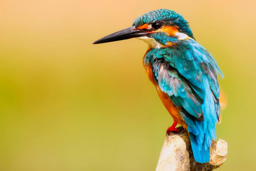

In [17]:
from fastai.vision.all import *
from fastdownload import download_url
from pathlib import Path

def show_image(path: Path, url: str) -> None:
    if not path.exists():
        download_url(url, path)
    display(Image.open(dest).to_thumb(256, 256))

dest = Path("images") / "forest.jpeg"
opened_image = show_image(dest, urls[0])

In [18]:
bear_types = 'grizzly','black','teddy'
path = Path('bears')

In [19]:
if not path.exists():
    path.mkdir()

for o in bear_types:
    dest = (path / o)
    dest.mkdir(exist_ok=True)
    urls = search_images(f"{o} bear", max_images=150)
    download_images(dest, urls=urls)

python(3841) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3898) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3932) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [20]:
fns = get_image_files(path)
fns

(#279) [Path('bears/grizzly/908a820b-e182-4cdd-82e0-871ab32326d9.jpg'),Path('bears/grizzly/6302008e-0f08-463d-8a32-95ad34b1fa6a.jpg'),Path('bears/grizzly/bf1fe01e-e014-4048-a473-37071e124516.jpg'),Path('bears/grizzly/c9acc83e-6490-43ac-aca8-6b12d6d27099.jpg'),Path('bears/grizzly/c0c0e274-1114-4d54-abf7-b0bac62cf921.jpg'),Path('bears/grizzly/5203df24-108c-4cf8-a75d-0995ba1d07bf.jpg'),Path('bears/grizzly/6122ac0a-b786-4a17-bede-be7a7f0af507.jpg'),Path('bears/grizzly/f9afd402-6d8f-446e-b97c-6c8ab1ccb850.jpg'),Path('bears/grizzly/d709afb7-65af-4d72-864c-a875396b2562.jpg'),Path('bears/grizzly/2a2647d1-88fe-456c-8c2c-96a2f7a807d4.jpg'),Path('bears/grizzly/59fe8d98-5627-4cef-a526-5603d4f62acc.webp'),Path('bears/grizzly/22ba85d1-729e-4818-a50e-dcdb87a2f670.png'),Path('bears/grizzly/983cb2db-2605-4fdc-a790-200c55d43f7f.jpg'),Path('bears/grizzly/54af4bef-f1d8-4fd2-8925-af1beca0fe26.jpg'),Path('bears/grizzly/fdafccda-5106-4429-ac03-5c21d0c85d85.jpg'),Path('bears/grizzly/86939f3f-52fe-4a94-97f2-75

In [21]:
failed = verify_images(fns)
failed

python(3954) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3955) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3956) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3957) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3958) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3959) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3960) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3961) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3962) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3963) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3964) MallocStackLoggin

(#0) []

In [22]:
failed.map(Path.unlink)

(#0) []

In [23]:
??verify_images

Signature: verify_images(fns)
Source:   
def verify_images(fns):
    "Find images in `fns` that can't be opened"
    return L(fns[i] for i,o in enumerate(parallel(verify_image, fns)) if not o)
File:      ~/epam/dl-practitioner/.venv/lib/python3.11/site-packages/fastai/vision/utils.py
Type:      function

In [24]:
doc(verify_images)

verify_images(fns)
Find images in `fns` that can't be opened

To get a prettier result with hyperlinks to source code and documentation, install nbdev: pip install nbdev


In [25]:
from fastbook import *
from fastai.vision.widgets import *

path = Path('bears')

bears = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128))

In [26]:
dls = bears.dataloaders(path)

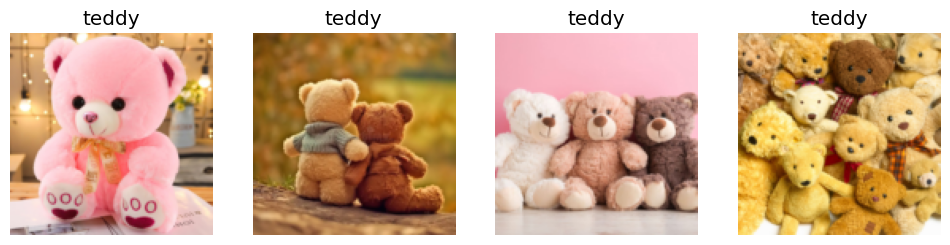

In [27]:
dls.valid.show_batch(max_n=4, nrows=1)

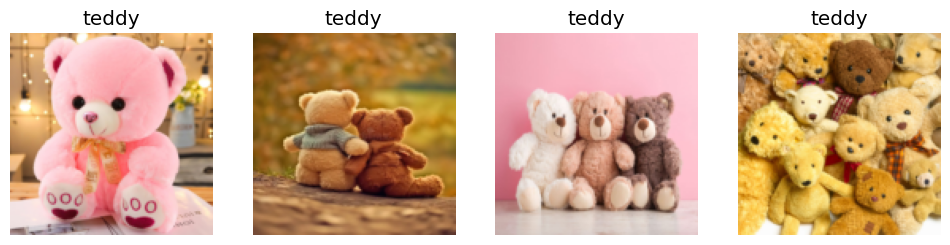

In [28]:
bears = bears.new(item_tfms=Resize(128, ResizeMethod.Squish))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

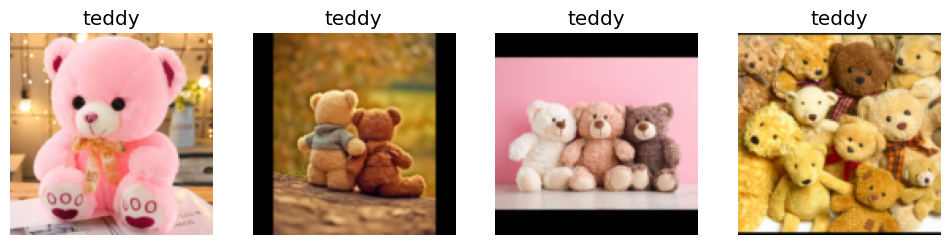

In [29]:
bears = bears.new(item_tfms=Resize(128, ResizeMethod.Pad, pad_mode='zeros'))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

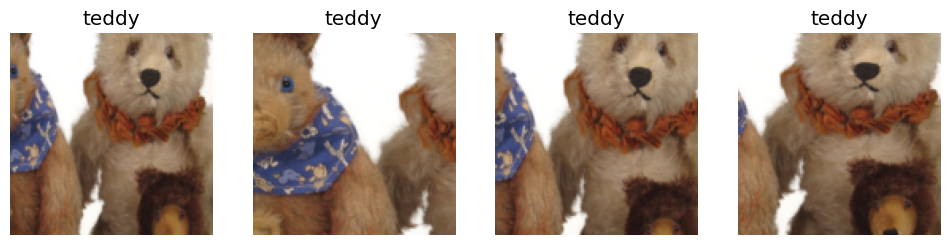

In [30]:
bears = bears.new(item_tfms=RandomResizedCrop(128, min_scale=0.3))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=4, nrows=1, unique=True)

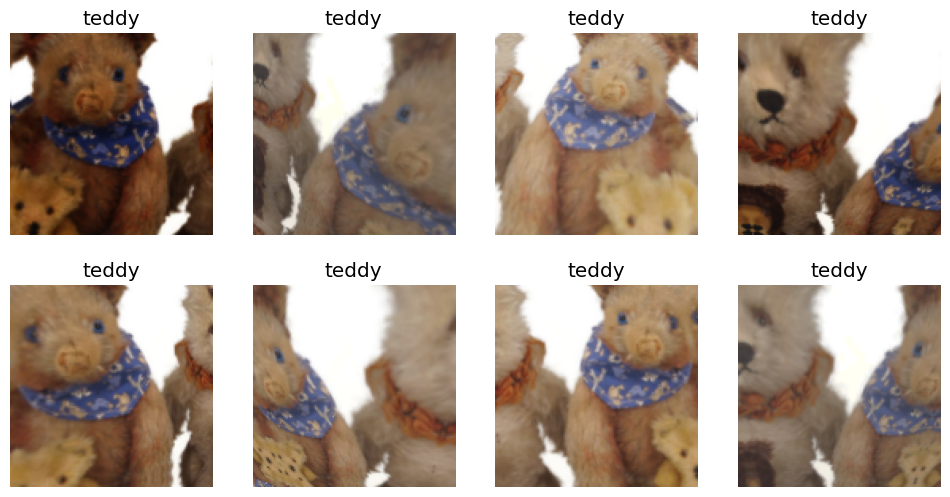

In [ ]:
bears = bears.new(item_tfms=Resize(128), batch_tfms=aug_transforms(mult=2))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=8, nrows=2, unique=True)

In [32]:
bears = bears.new(
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms())
dls = bears.dataloaders(path)

In [33]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/aidardarmesh/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:06<00:00, 7.52MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,2.037619,0.742579,0.272727,00:09


/Users/aidardarmesh/epam/dl-practitioner/.venv/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,error_rate,time
0,0.327140,0.075007,0.036364,00:05
1,0.211699,0.007544,0.000000,00:04
2,0.145356,0.003395,0.000000,00:04
3,0.130402,0.001960,0.000000,00:04


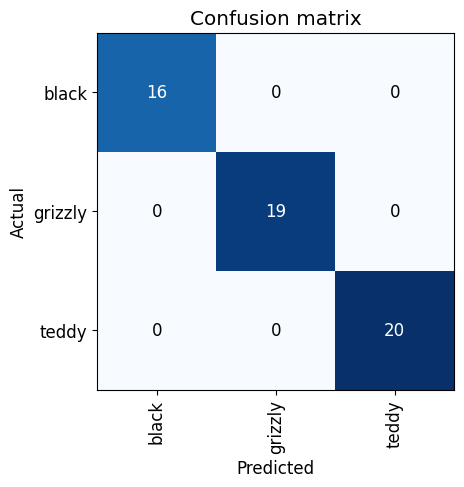

In [34]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

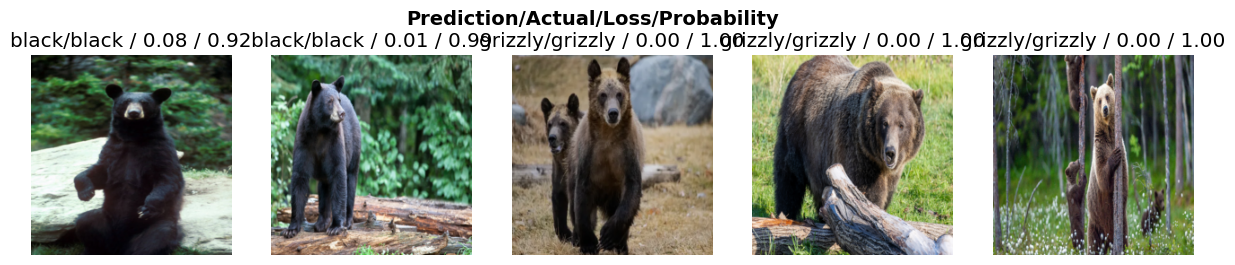

In [35]:
interp.plot_top_losses(5, nrows=1)

In [36]:
#hide_output
cleaner = ImageClassifierCleaner(learn)
cleaner

/Users/aidardarmesh/epam/dl-practitioner/.venv/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


python(5386) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5388) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5389) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5390) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [58]:
learn.export('export.pkl', pickle_protocol=4)

In [38]:
path = Path()
path.ls(file_exts='.pkl')

(#1) [Path('export.pkl')]

In [39]:
learn_inf = load_learner(Path('export.pkl'))

/Users/aidardarmesh/epam/dl-practitioner/.venv/lib/python3.11/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [41]:
learn_inf.predict('bears/grizzly/0d5fa484-1d90-4c13-a0da-455aa85bcbba.jpg')

('grizzly', tensor(1), tensor([1.3329e-03, 9.9867e-01, 5.4689e-07]))

In [42]:
learn_inf.dls.vocab

['black', 'grizzly', 'teddy']

In [43]:
#hide_output
btn_upload = widgets.FileUpload()
btn_upload

FileUpload(value={}, description='Upload')

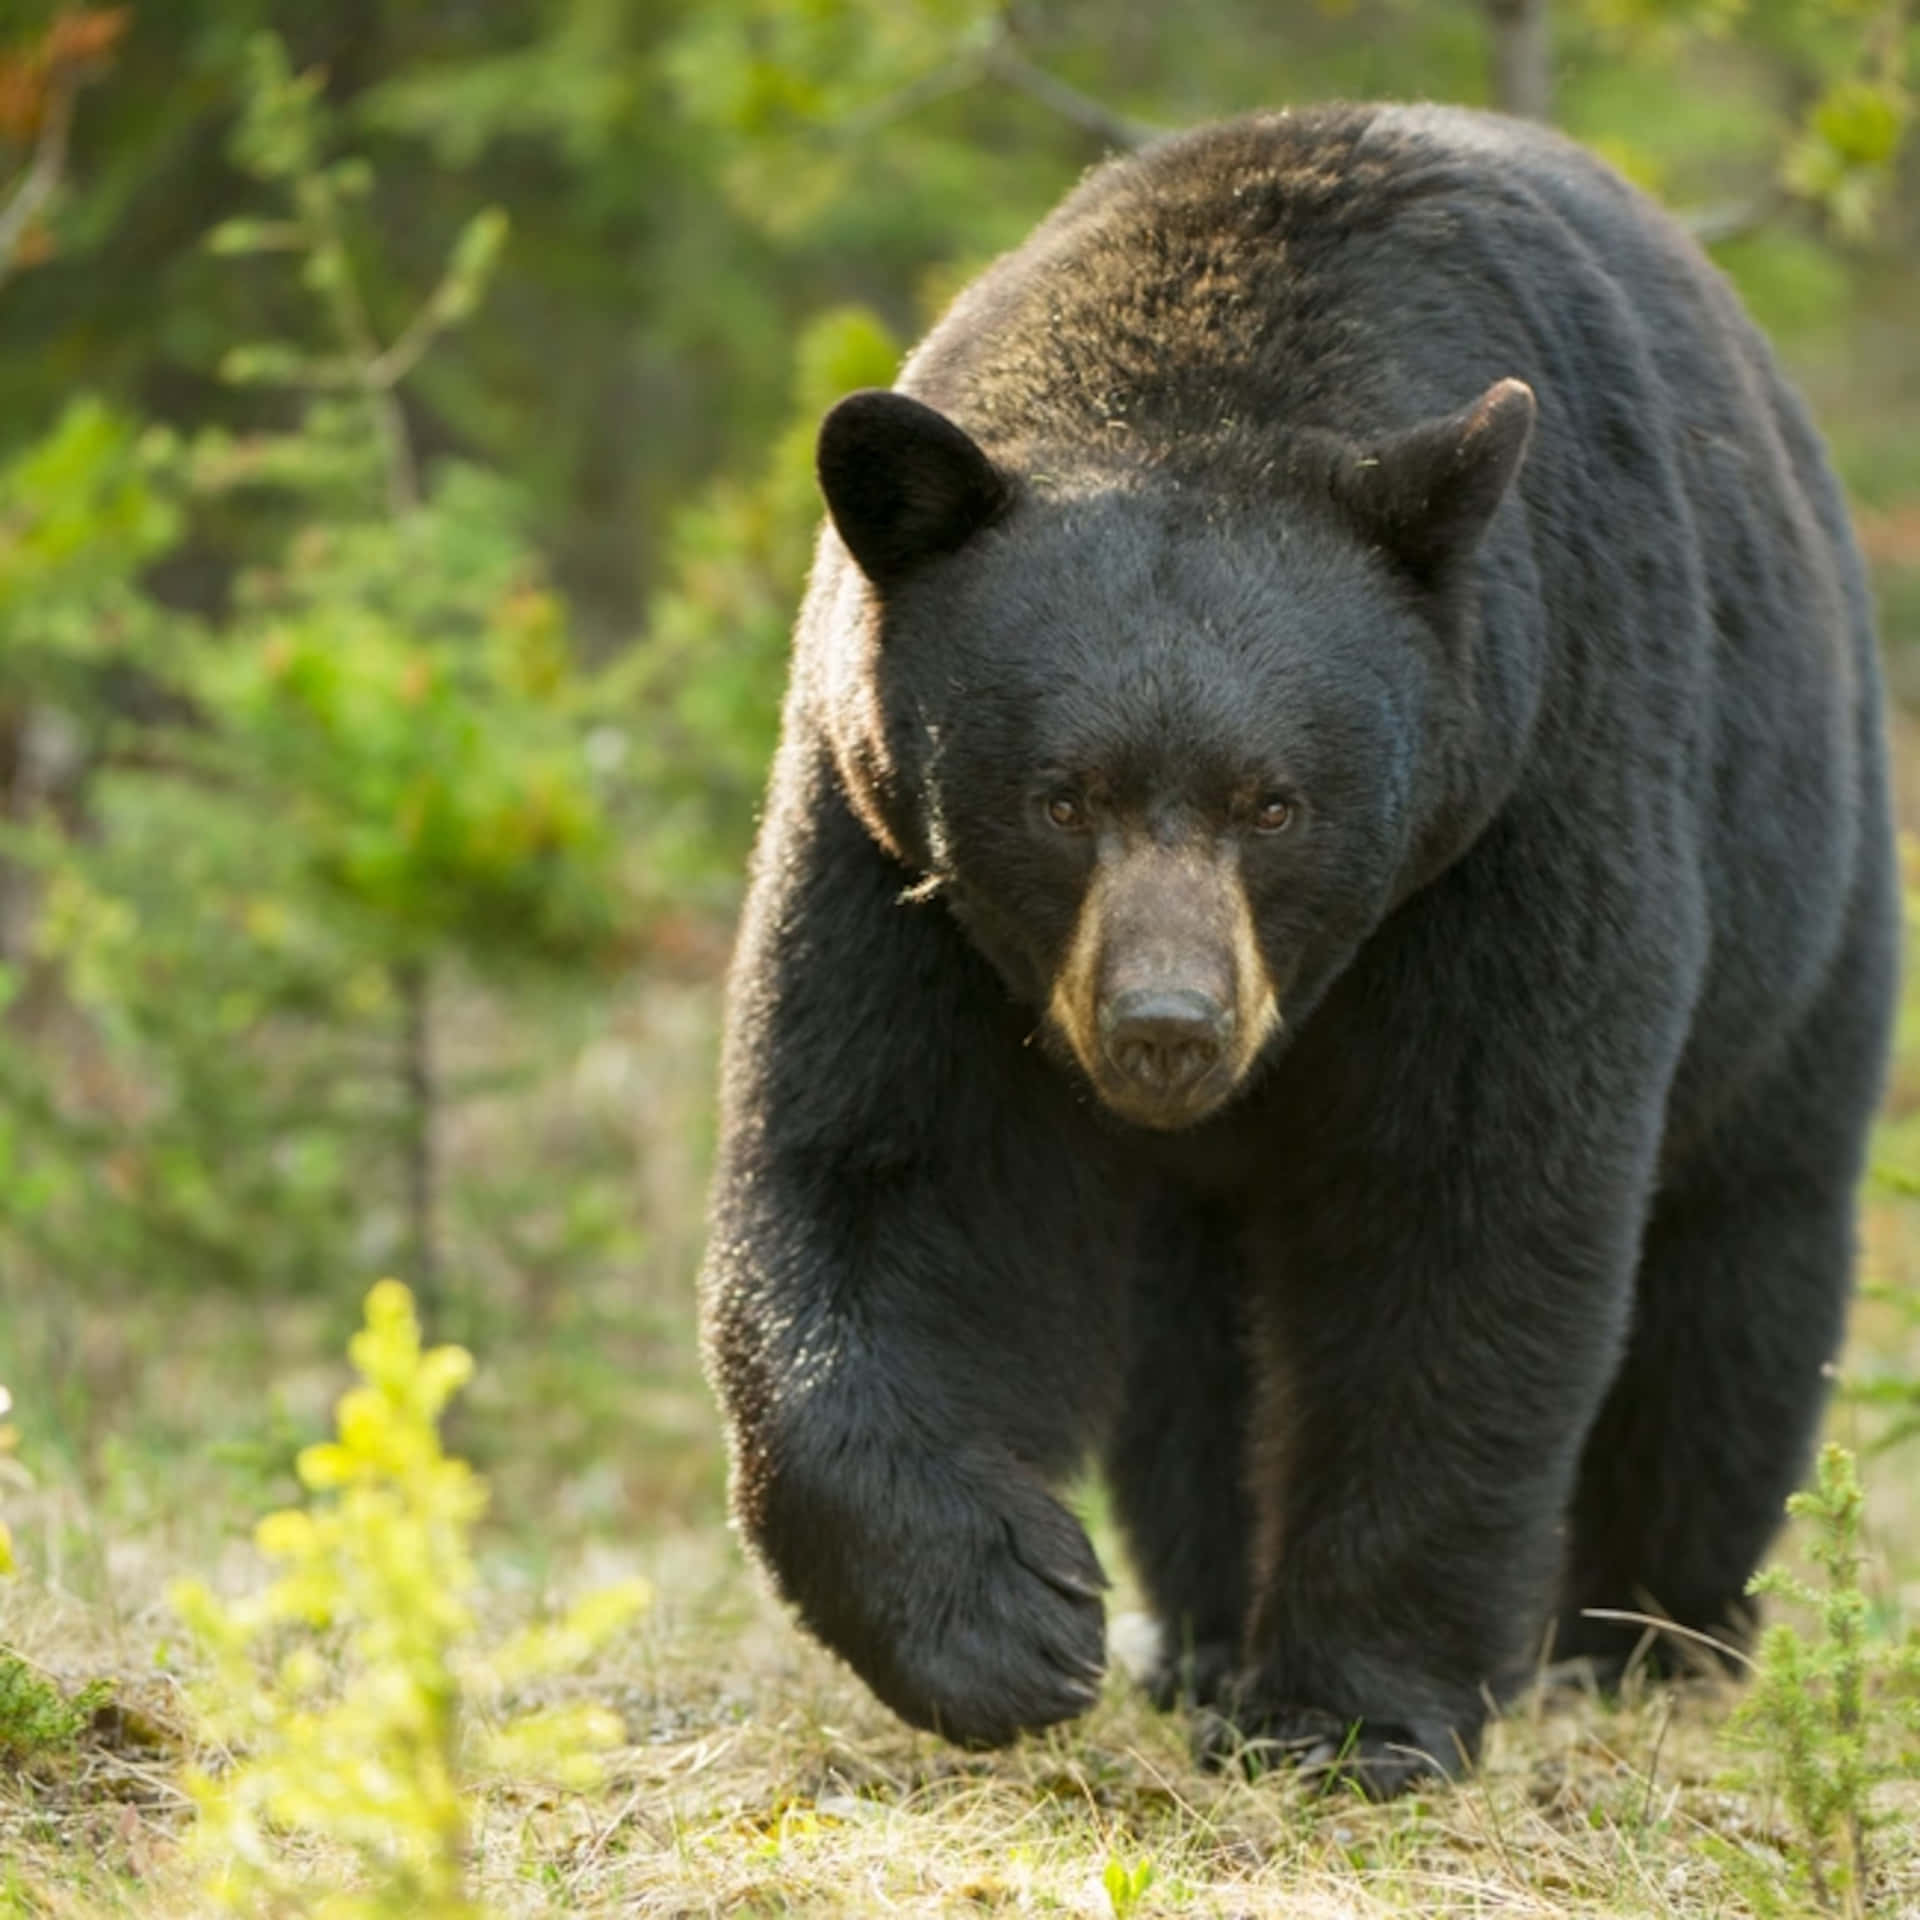

In [46]:
img = PILImage.create(btn_upload.data[-1])
img

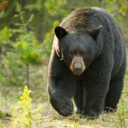

In [47]:
display(img.to_thumb(128,128))

In [48]:
pred,pred_idx,probs = learn_inf.predict(img)

In [49]:
#hide_output
lbl_pred = widgets.Label()
lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'
lbl_pred

Label(value='Prediction: black; Probability: 0.9994')

In [ ]:
#hide_output
btn_run = widgets.Button(description='Classify')
btn_run

Button(description='Classify', style=ButtonStyle())

In [51]:
def on_click_classify(change):
    img = PILImage.create(btn_upload.data[-1])
    out_pl.clear_output()
    with out_pl: display(img.to_thumb(128,128))
    pred,pred_idx,probs = learn_inf.predict(img)
    lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'

btn_run.on_click(on_click_classify)

In [52]:
#hide
#Putting back btn_upload to a widget for next cell
btn_upload = widgets.FileUpload()

In [53]:
#hide_output
VBox([widgets.Label('Select your bear!'), 
      btn_upload, btn_run, out_pl, lbl_pred])

In [54]:
!pip install voila

python(9054) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 5.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [voila]


In [56]:
!jupyter serverextension enable --sys-prefix voila

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: dejavu events execute kernel kernelspec lab
labextension labhub migrate nbconvert notebook run server troubleshoot trust

Jupyter command `jupyter-serverextension` not found.


python(9555) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
